In [6]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

In [5]:
dfv = pd.read_csv("./data/flow_10.23-03.24.csv")
dfv.loc[:,'timestamp'] = pd.to_datetime(dfv['timestamp'], errors='coerce')
dfv.set_index("timestamp",inplace=True)

c:\Program Files\Python311\Lib\site-packages\pandas\core\indexes\base.py:7588: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)


In [8]:
df = pd.read_csv('./result_csv/data_matrix.csv')
to_remove = pd.read_csv('./result_csv/to_remove.csv')
df.loc[:,'timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df.set_index("timestamp",inplace=True)
df.drop(columns=list(to_remove['to_remove']), inplace=True)

c:\Program Files\Python311\Lib\site-packages\pandas\core\indexes\base.py:7588: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)


In [10]:
df_new = pd.read_csv('./result_csv/corr_matrix_profile.csv')
df_new.loc[:,'timestamp'] = pd.to_datetime(df_new['timestamp'], errors='coerce')
df_new.set_index("timestamp",inplace=True)

c:\Program Files\Python311\Lib\site-packages\pandas\core\indexes\base.py:7588: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)


In [12]:
np.random.seed(40)
mask = np.random.rand(*df.shape) < 0.2

# Create the 20% matrix (for test dataset)
df_20 = df.where(mask)
# Create the 80% matrix (for training dataset)
df_80 = df.where(~mask)

df_new_20 = df_new.where(mask)
df_new_80 = df_new.where(~mask)

In [13]:
from sklearn.preprocessing import OneHotEncoder

# Function to create one-hot encoded labels
def create_one_hot_labels(detectors):
    enc = OneHotEncoder(sparse_output=False)
    detectors_reshaped = np.array(detectors).reshape(-1, 1)
    enc.fit(detectors_reshaped)
    return enc
detectors = df.columns.tolist()
one_hot_encoder = create_one_hot_labels(detectors)
one_hot_encoder

OneHotEncoder(sparse_output=False)

In [14]:
dfv = dfv.fillna(0)

In [15]:
X = []
y = []

# Iterate over each detector
for day in df.index:
    for detector in detectors:
        if df_80.at[day, detector] == 1:
            start = day
            end = start + pd.Timedelta(days=1) - pd.Timedelta(minutes=2)
            weekday_number = start.date().weekday()
            one_hot_day = np.eye(7)[1]

            # Get data for the current day
            daily_data = dfv[start:end][detector+'_total_flow'].values

            if len(daily_data) == 720:  # Ensure we have exactly 720 samples (24 hours * 30 samples per hour)
                # Append daily data and corresponding label
                features = np.hstack((one_hot_day, daily_data))

                X.append(features)
                y.append(one_hot_encoder.transform([[detector]])[0])
            else:
                print("error")
                
X_train = np.array(X, dtype=np.float32) 
y_train = np.array(y, dtype=np.float32)  



In [16]:
print("X shape:", X_train.shape)  # Should be (number of samples, 720)
print("y shape:", y_train.shape)

scaler = StandardScaler()

X_train_normalized = scaler.fit_transform(X_train)
X_train_tensor = torch.tensor(X_train_normalized)
y_train_tensor = torch.tensor(y_train)

X shape: (80087, 727)
y shape: (80087, 600)


In [17]:
class MLP_attention(nn.Module):
    def __init__(self,num_classes):
        super(MLP_attention, self).__init__()
        # Branch for day of the week
        self.day_branch = nn.Sequential(
            nn.Linear(7, 32),  # Processing numeric day of week
            nn.ReLU(),
            nn.Linear(32, 32),  
            nn.ReLU(),
        )
        
        # Branch for other features
        self.feature_branch = nn.Sequential(
            nn.Linear(720, 128),  # Assuming 720 other features
            nn.ReLU(),
            # nn.Linear(128, 128),
            # nn.ReLU(),
        )
        
        # Combine branches
        self.combined_branch = nn.Sequential(
            nn.Linear(32 + 128, 32),
            nn.ReLU(),
            nn.Linear(32, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)  # Output layer
        )

    def forward(self, x):
        day_features = x[:, :7]  # Assuming first column is the numeric day of the week
        other_features = x[:, 7:]  # Rest are other features
        
        day_output = self.day_branch(day_features)
        feature_output = self.feature_branch(other_features)
        
        combined = torch.cat((day_output, feature_output), dim=1)
        output = self.combined_branch(combined)
        
        return output

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [19]:
X_train_tensor = X_train_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)
num_classes = y_train_tensor.shape[1]

In [21]:
model = MLP_attention(num_classes).to(device)
model_name = model.__class__.__name__
criterion = nn.CrossEntropyLoss()
lr = 0.001
wd = 0.001
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)

train_losses = []
train_accuracies = []

# Variables to track highest val accuracy and corresponding model state
epochs = 3000
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    total_predictions = 0
    correct_predictions = 0

    # Forward pass
    outputs = model(X_train_tensor)
    
    # Compute training loss
    loss = criterion(outputs, y_train_tensor)
    
    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # Calculate training loss
    running_loss = loss.item()

    # Compute training predictions and accuracy
    _, predicted_train = torch.max(outputs, 1)
    total_predictions_train = y_train_tensor.size(0)
    correct_predictions_train = (predicted_train == y_train_tensor.argmax(dim=1)).sum().item()  # Convert one-hot encoded labels to class indices
    
    # Calculate training accuracy
    accuracy_train = correct_predictions_train / total_predictions_train
    
    
    # Append current epoch loss and accuracy to arrays
    train_losses.append(running_loss)
    train_accuracies.append(accuracy_train)
    

    torch.save(model.state_dict(), './model_profile/' + model_name + '_lr-' + str(lr) + '_wd-' + str(wd) + '_analysis' + '.pth')
    
    if (epoch + 1) % 50 == 0:
        # Print epoch loss and accuracy for both training and valing
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {running_loss}, Train Acc: {accuracy_train}")
    
    elif (epoch + 1) == epochs:
        # Print final epoch loss and accuracy for training
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {running_loss}, Train Acc: {accuracy_train}")

Epoch 50/3000, Train Loss: 4.41909122467041, Train Acc: 0.06781375254410828
Epoch 100/3000, Train Loss: 2.7136940956115723, Train Acc: 0.3100003745926305
Epoch 150/3000, Train Loss: 2.066380023956299, Train Acc: 0.4420817361119782
Epoch 200/3000, Train Loss: 1.7458720207214355, Train Acc: 0.5094834367625207
Epoch 250/3000, Train Loss: 1.5707674026489258, Train Acc: 0.5464307565522494
Epoch 300/3000, Train Loss: 1.441802740097046, Train Acc: 0.5743379075255659
Epoch 350/3000, Train Loss: 1.346277117729187, Train Acc: 0.5957646059909848
Epoch 400/3000, Train Loss: 1.2761011123657227, Train Acc: 0.6095121555308602
Epoch 450/3000, Train Loss: 1.2168718576431274, Train Acc: 0.6222607913893641
Epoch 500/3000, Train Loss: 1.1681429147720337, Train Acc: 0.632849276411902
Epoch 550/3000, Train Loss: 1.1267821788787842, Train Acc: 0.6435251663815601
Epoch 600/3000, Train Loss: 1.0939964056015015, Train Acc: 0.6505425349931949
Epoch 650/3000, Train Loss: 1.0652798414230347, Train Acc: 0.656523530

In [20]:
df_triplets = pd.read_csv('./result_csv/triplets.csv')
df_duets = pd.read_csv('./result_csv/duets.csv')
print(df_triplets.to_string())

                  0               1               2
0          AID01101        AID01102        AID01103
1          AID01102        AID01103        AID01104
2          AID01103        AID01104        AID01105
3          AID01104        AID01105        AID01106
4          AID01105        AID01106        AID01107
5          AID01108        AID01109        AID01110
6          AID01111        AID01112        AID01113
7          AID01112        AID01113        AID01114
8          AID01113        AID01114        AID01115
9          AID01114        AID01115        AID01116
10         AID01115        AID01116        AID01117
11         AID01116        AID01117        AID01118
12         AID01117        AID01118        AID01119
13         AID01118        AID01119        AID01120
14         AID01119        AID01120        AID01121
15         AID01120        AID01121        AID01122
16         AID01121        AID01122        AID01123
17         AID01124        AID01125        AID01126
18         A

In [21]:
df_result = pd.DataFrame(np.nan, index=df.index, columns=df.columns)
num_classes = 600

In [23]:
# df_result.isna().sum()

In [25]:
# # Create the result rank matrix for the input data

# model = MLP_attention(num_classes).to(device) 
# criterion = nn.CrossEntropyLoss()
# model.load_state_dict(torch.load('./model_profile/MLP_attention_lr-0.001_wd-0.001_analysis.pth'))
# model.eval()  # Set the model to evaluation mode

# for idx in df.index:
#     for i in df.columns:

#         if(df.loc[idx,i]==np.nan):
#             continue
        
#         start = idx
#         end = start + pd.Timedelta(days=1) - pd.Timedelta(minutes=2)
#         weekday_number = start.date().weekday()
#         one_hot_day = np.eye(7)[1]

#         # Get data for the current day
#         daily_data = dfv[start:end][i+'_total_flow'].values

#         if len(daily_data) == 720:  # Ensure we have exactly 720 samples (24 hours * 30 samples per hour)
#             # Append daily data and corresponding label
#             features = np.hstack((one_hot_day, daily_data))
            
#             # Create X and y
#             X = [features]  # Add a new axis to make it 2D
#             y = [one_hot_encoder.transform([[i]])[0]]

#             X = np.array(X, dtype=np.float32) 
#             y = np.array(y, dtype=np.float32) 

#             X = scaler.transform(X)
#             X_tensor = torch.tensor(X).to(device)
#             y_tensor = torch.tensor(y).to(device)            

#             # Feed into model and calculate accuracy
#             with torch.no_grad():
#                 outputs = model(X_tensor)

#                 ranks = torch.argsort(outputs, dim=1, descending=True)

#                 correct_index = torch.argmax(y_tensor).item()
#                 correct_rank = torch.where(ranks == correct_index)[1].item() + 1
#                 df_result.loc[idx,i] = correct_rank
                

                

In [77]:
# print(df_result.to_string())

            AID01101  AID01102  AID01103  AID01104  AID01105  AID01106  AID01107  AID01108  AID01109  AID01110  AID01111  AID01112  AID01113  AID01114  AID01115  AID01116  AID01117  AID01118  AID01119  AID01120  AID01121  AID01122  AID01124  AID01125  AID01126  AID01127  AID01128  AID01129  AID01131  AID01132  AID01133  AID01134  AID01135  AID01136  AID01201  AID01202  AID01203  AID01204  AID01205  AID01206  AID01207  AID01208  AID01209  AID01210  AID01211  AID01212  AID01214  AID01215  AID01216  AID01217  AID01218  AID01219  AID01220  AID01221  AID01222  AID01223  AID02104  AID02105  AID02106  AID02107  AID02108  AID02109  AID02110  AID02111  AID02112  AID02113  AID02114  AID02115  AID02116  AID02117  AID02118  AID02119  AID02120  AID02121  AID02122  AID02123  AID02124  AID02125  AID02126  AID02127  AID02201  AID02202  AID02203  AID02204  AID02205  AID02206  AID02207  AID02208  AID02209  AID02210  AID02211  AID02212  AID02213  AID02214  AID02215  AID03106  AID03107  AID03108  AID03109

In [30]:
# df_result.to_csv('data_matrix_result_rank.csv') 
# Note this matrix has predicted rank of the detector in it and not binary values.
df_result = pd.read_csv('./result_csv/profile_matrix_result_rank.csv')
df_result.loc[:,'timestamp'] = pd.to_datetime(df_result['timestamp'], errors='coerce')
df_result.set_index("timestamp",inplace=True)

c:\Program Files\Python311\Lib\site-packages\pandas\core\indexes\base.py:7588: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)


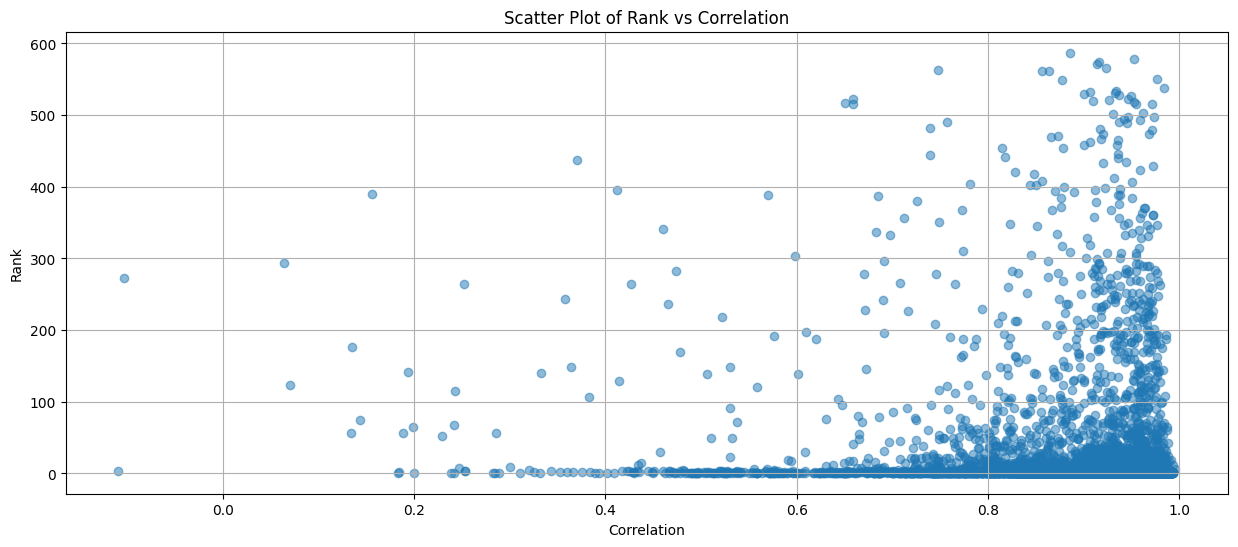

In [31]:
corr_flat = df_new_20.values.flatten()
rank_flat = df_result.values.flatten()

# Create scatter plot
plt.figure(figsize=(15, 6))
plt.scatter(corr_flat, rank_flat, alpha=0.5)
plt.xlabel('Correlation')
plt.ylabel('Rank')
plt.title('Scatter Plot of Rank vs Correlation')
plt.grid(True)
plt.show()

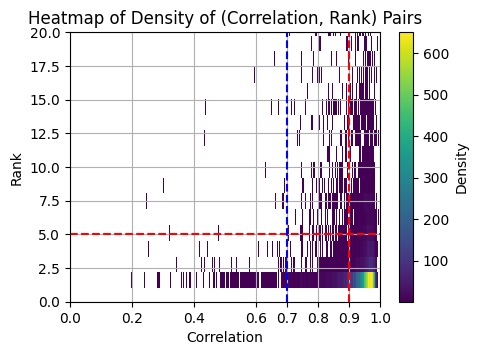

In [32]:
mask = ~np.isnan(corr_flat) & ~np.isnan(rank_flat)
corr_filtered = corr_flat[mask]
rank_filtered = rank_flat[mask]
rank_filtered_ = np.array(rank_filtered)
rank_filtered_ = np.clip(rank_filtered_, None, 75)

# Create a 2D histogram (heatmap) of (corr, rank) pairs, ignoring NaN values
plt.figure(figsize=(5, 3.5))
plt.hist2d(corr_filtered, rank_filtered, bins=500, cmap='viridis', cmin=1)
plt.colorbar(label='Density')
plt.xlabel('Correlation')
plt.ylabel('Rank')
plt.xlim(0.19,1)
plt.ylim(0,20)
plt.title('Heatmap of Density of (Correlation, Rank) Pairs')
plt.grid(True)
plt.axhline(y=5, color='red', linestyle='--')
plt.axvline(x=0.9, color='red', linestyle='--')
plt.axvline(x=0.7, color='blue', linestyle='--')
current_xticks = plt.xticks()[0]
plt.xticks(list(current_xticks) + [0.7, 0.9])
plt.show()

In [35]:
# for detector in df_new_20.columns:
#     for idx in df_new_20.index:
    
#         corr = df_new_20.loc[idx,detector]
#         rank = df_result.loc[idx,detector]
#         if(np.isnan(corr)):
#             continue

#         if (corr>0.9 and rank>10 ):
#             print(idx,detector, rank)

[20 15 20 ... 20 10 20]


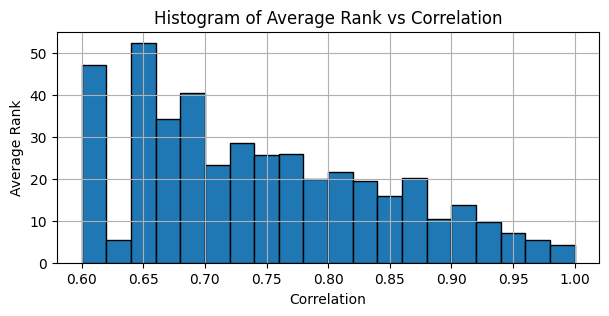

In [36]:
num_bins = 20

# Compute the bin edges and digitize the correlation data
bin_edges = np.linspace(0.6, 1, num_bins + 1)
bin_indices = np.digitize(corr_flat, bin_edges) - 1
print(bin_indices)
# Initialize an array to store the average rank for each bin
average_rank_per_bin = np.zeros(num_bins)

# Compute the average rank for each bin
for i in range(num_bins):
    average_rank_per_bin[i] = np.mean(rank_flat[bin_indices == i])

# Plot the histogram
plt.figure(figsize=(7, 3))
plt.bar(bin_edges[:-1], average_rank_per_bin, width=np.diff(bin_edges), align='edge', edgecolor='k')
plt.xlabel('Correlation')
plt.ylabel('Average Rank')
plt.title('Histogram of Average Rank vs Correlation')
plt.grid(True)
plt.show()